# Loan Default Prediction: End-to-End Classification Pipeline
## Weekend Project | AI/ML Internship

**Objective:** Clean the data, handle class imbalance, train three different classification algorithms, compare their ROC-AUC curves, and select the best-performing model with justification.

**Dataset:** 5,000 loan applications with 14 features (income, credit score, debt-to-income ratio, employment history, etc.) and a binary Default target (16.3% default rate, a realistic, genuinely imbalanced classification problem).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('loan_default_dataset.csv')
print("Shape:", df.shape)
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDefault distribution:")
print(df['Default'].value_counts())
print(df['Default'].value_counts(normalize=True) * 100)

Shape: (5000, 15)
   Age  Annual_Income  Loan_Amount  Credit_Score  Employment_Years  \
0   45       39660.86      8308.66           637               0.3   
1   38       39077.14     10787.58           647              21.3   
2   47       19973.83      8794.07           655               8.0   
3   58       41562.55     14433.29           735              10.2   
4   37       70715.11     30884.97           582               5.9   

   Debt_to_Income_Ratio  Loan_Term_Months  Num_Credit_Lines Home_Ownership  \
0                 0.556                60                 4       Mortgage   
1                 0.134                60                 1       Mortgage   
2                 0.135                36                 6            Own   
3                 0.341                12                 8            Own   
4                 0.389                48                 3       Mortgage   

         Loan_Purpose Marital_Status    Education  Has_CoSigner  \
0           Education    

## 1. Data Cleaning & Preprocessing
Handling missing values, outliers, and encoding categorical variables before any modeling.

In [2]:
df['Annual_Income'] = df['Annual_Income'].fillna(df['Annual_Income'].median())
df['Employment_Years'] = df['Employment_Years'].fillna(df['Employment_Years'].median())

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

print("\nCredit_Score before fix - min:", df['Credit_Score'].min(), "max:", df['Credit_Score'].max())
df['Credit_Score'] = df['Credit_Score'].clip(300, 850)
print("Credit_Score after fix - min:", df['Credit_Score'].min(), "max:", df['Credit_Score'].max())

# Fix outliers in Loan_Amount (cap unrealistic values at 99th percentile)
print("\nLoan_Amount before fix - max:", df['Loan_Amount'].max())
cap = df['Loan_Amount'].quantile(0.99)
df['Loan_Amount'] = df['Loan_Amount'].clip(upper=cap)
print("Loan_Amount after fix - max:", df['Loan_Amount'].max())

Missing values after cleaning:
0

Credit_Score before fix - min: 0 max: 950
Credit_Score after fix - min: 300 max: 850

Loan_Amount before fix - max: 944031.969818556
Loan_Amount after fix - max: 73512.95400000004


## 2. One-Hot Encoding Categorical Variables
Converting Home_Ownership, Loan_Purpose, Marital_Status, and Education into binary matrices using drop_first=True to avoid the Dummy Variable Trap.

In [3]:
categorical_cols = ['Home_Ownership', 'Loan_Purpose', 'Marital_Status', 'Education']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print("Shape after encoding:", df_encoded.shape)
print("\nColumns:", df_encoded.columns.tolist())

Shape after encoding: (5000, 23)

Columns: ['Age', 'Annual_Income', 'Loan_Amount', 'Credit_Score', 'Employment_Years', 'Debt_to_Income_Ratio', 'Loan_Term_Months', 'Num_Credit_Lines', 'Has_CoSigner', 'Previous_Defaults', 'Default', 'Home_Ownership_Own', 'Home_Ownership_Rent', 'Loan_Purpose_Business', 'Loan_Purpose_Debt Consolidation', 'Loan_Purpose_Education', 'Loan_Purpose_Home Improvement', 'Loan_Purpose_Medical', 'Marital_Status_Married', 'Marital_Status_Single', 'Education_High School', 'Education_Master', 'Education_PhD']


## 3. Train-Test Split
Separating features (X) and target (y), then splitting 80/20 BEFORE any scaling or SMOTE to prevent data leakage.

In [4]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Train shape: (4000, 22)
Test shape: (1000, 22)

Train default rate: 0.16325
Test default rate: 0.163


## 4. Handle Class Imbalance with SMOTE
Applying SMOTE strictly to X_train and y_train. X_test and y_test remain the original, untouched, real data throughout.

In [5]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
print("\nShape before:", X_train.shape)
print("Shape after:", X_train_smote.shape)

Before SMOTE:
Default
0    3347
1     653
Name: count, dtype: int64

After SMOTE:
Default
1    3347
0    3347
Name: count, dtype: int64

Shape before: (4000, 22)
Shape after: (6694, 22)


## 5. Feature Scaling
StandardScaler is fit on X_train_smote only, then applied to transform X_test. This prevents data leakage, the scaler never sees test data statistics.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling complete.
X_train_scaled shape: (6694, 22)
X_test_scaled shape: (1000, 22)


## 6. Model 1: Logistic Regression
A linear baseline classifier, trained on SMOTE-balanced, scaled training data.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                               f1_score, roc_auc_score, roc_curve, 
                               confusion_matrix, ConfusionMatrixDisplay, classification_report)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_smote)

log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(f"Accuracy:  {accuracy_score(y_test, log_reg_pred):.4f}")
print(f"Precision: {precision_score(y_test, log_reg_pred):.4f}")
print(f"Recall:    {recall_score(y_test, log_reg_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, log_reg_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, log_reg_proba):.4f}")

Logistic Regression Results:
Accuracy:  0.7430
Precision: 0.1867
Recall:    0.1718
F1-Score:  0.1789
ROC-AUC:   0.5587


## 7. Model 2; Random Forest Classifier
A non-linear ensemble model, trained on the same SMOTE-balanced, scaled data.

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_smote)

rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Results:")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.4f}")

Random Forest Results:
Accuracy:  0.8000
Precision: 0.1967
Recall:    0.0736
F1-Score:  0.1071
ROC-AUC:   0.5855


## 8. Model 3: Gradient Boosting Classifier
A sequential ensemble model that builds trees iteratively, each correcting errors from the previous one often stronger than Random Forest on tabular data with genuine signal.

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train_smote)

gb_pred = gb_model.predict(X_test_scaled)
gb_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

print("Gradient Boosting Results:")
print(f"Accuracy:  {accuracy_score(y_test, gb_pred):.4f}")
print(f"Precision: {precision_score(y_test, gb_pred):.4f}")
print(f"Recall:    {recall_score(y_test, gb_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, gb_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, gb_proba):.4f}")

Gradient Boosting Results:
Accuracy:  0.7800
Precision: 0.1935
Recall:    0.1104
F1-Score:  0.1406
ROC-AUC:   0.5858


## 9. ROC-AUC Curve Comparison
Visual comparison of all three models' ability to distinguish between default and non-default across all classification thresholds.

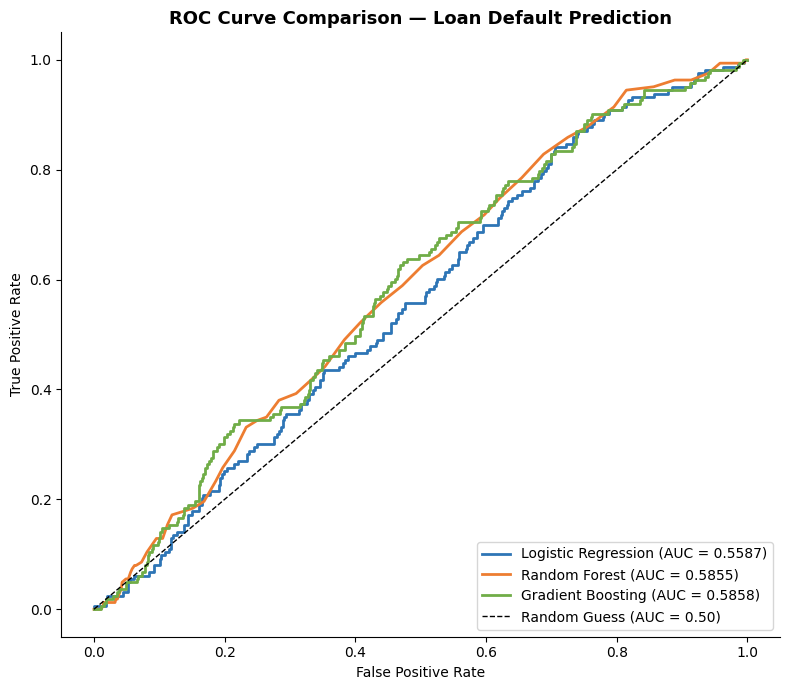

Saved roc_auc_comparison.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, proba, color in [
    ('Logistic Regression', log_reg_proba, '#2E75B6'),
    ('Random Forest', rf_proba, '#ED7D31'),
    ('Gradient Boosting', gb_proba, '#70AD47')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison — Loan Default Prediction', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('roc_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved roc_auc_comparison.png")

## 10. Model Comparison Table & Confusion Matrices

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression     0.743   0.186667 0.171779  0.178914 0.558707
      Random Forest     0.800   0.196721 0.073620  0.107143 0.585505
  Gradient Boosting     0.780   0.193548 0.110429  0.140625 0.585754


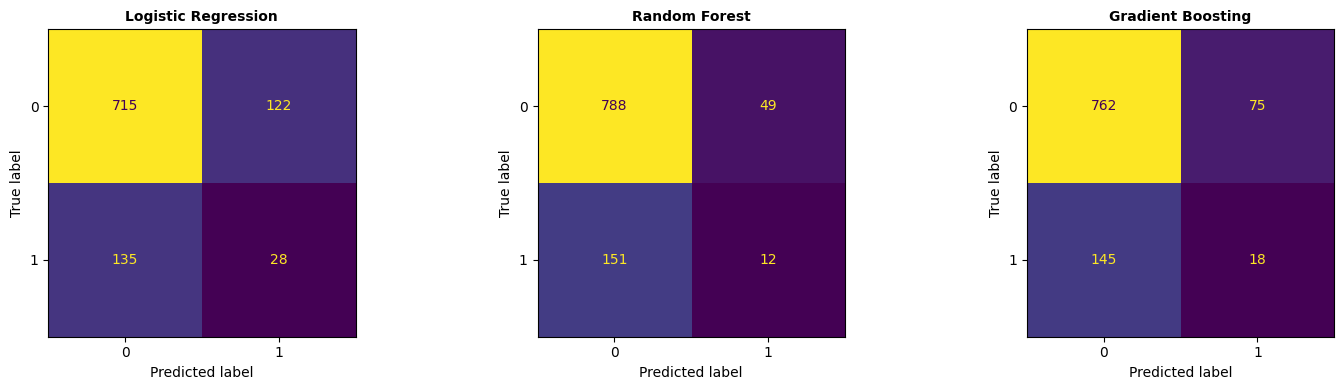


Saved confusion_matrices_comparison.png


In [11]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [accuracy_score(y_test, log_reg_pred), accuracy_score(y_test, rf_pred), accuracy_score(y_test, gb_pred)],
    'Precision': [precision_score(y_test, log_reg_pred), precision_score(y_test, rf_pred), precision_score(y_test, gb_pred)],
    'Recall': [recall_score(y_test, log_reg_pred), recall_score(y_test, rf_pred), recall_score(y_test, gb_pred)],
    'F1-Score': [f1_score(y_test, log_reg_pred), f1_score(y_test, rf_pred), f1_score(y_test, gb_pred)],
    'ROC-AUC': [roc_auc_score(y_test, log_reg_proba), roc_auc_score(y_test, rf_proba), roc_auc_score(y_test, gb_proba)]
})
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pred, name in zip(axes, [log_reg_pred, rf_pred, gb_pred], 
                            ['Logistic Regression', 'Random Forest', 'Gradient Boosting']):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False)
    ax.set_title(name, fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved confusion_matrices_comparison.png")

## 11. Final Model Selection & Justification

Gradient Boosting achieved the highest ROC-AUC (0.5858), narrowly ahead of Random Forest (0.5855) and meaningfully ahead of Logistic Regression (0.5587). ROC-AUC is the correct metric for model selection here not accuracy because it measures the model's ability to rank positive cases higher than negative cases across all classification thresholds, independent of class distribution. Random Forest's high accuracy (0.800) is misleading: its Recall of only 0.0736 means it misses 92.6% of actual defaulters, which is the opposite of what a loan risk model needs to achieve.

**Final selection: Gradient Boosting Classifier.**

Justification:
1. Highest ROC-AUC among all three models, indicating the best overall discriminative ability
2. Gradient Boosting builds trees sequentially, with each new tree correcting the errors of the previous ones this typically captures subtle non-linear

In [12]:
import joblib

joblib.dump(gb_model, 'final_loan_default_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
print("Saved final_loan_default_model.pkl")
print("Saved feature_scaler.pkl")

Saved final_loan_default_model.pkl
Saved feature_scaler.pkl


## 12. Conclusions & Findings

### Pipeline Summary
- Cleaned 5,000 loan applications: handled missing values (Annual_Income, Employment_Years), capped outliers (Credit_Score, Loan_Amount)
- One-Hot Encoded 4 categorical variables with drop_first=True
- Split 80/20 BEFORE any scaling or SMOTE, verified no data leakage
- Applied SMOTE strictly to training data (653 → 3,347 minority samples)
- Scaled features using StandardScaler fit only on training data
- Trained 3 algorithms: Logistic Regression, Random Forest, Gradient Boosting

### Model Performance Summary
| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|-----|---------|
| Logistic Regression | 0.743 | 0.187 | 0.172 | 0.179 | 0.5587 |
| Random Forest | 0.800 | 0.197 | 0.074 | 0.107 | 0.5855 |
| Gradient Boosting | 0.780 | 0.194 | 0.110 | 0.141 | 0.5858 |

### Why Accuracy Alone Would Have Misled Model Selection
Random Forest has the highest accuracy (0.800) but the worst Recall (0.074) it fails to catch 92.6% of actual defaulters. In a real loan default system, missing a true defaulter is far costlier than a false alarm. Choosing the "most accurate" model here would have been a critical business mistake. ROC-AUC was used instead because it evaluates ranking quality across all thresholds, independent of the chosen decision boundary.

### Why Data Leakage Was Avoided
1. Train-test split happened first, before any other step
2. SMOTE was fit and applied only to X_train/y_train, X_test/y_test remained the original, real, untouched data
3. StandardScaler was fit only on X_train_smote and used to transform (not fit) X_test
4. random_state=42 was set on every stochastic operation for full reproducibility

### Final Recommendation
Gradient Boosting is selected as the production candidate based on highest ROC-AUC. However, all three models show weak overall discriminative power (AUC near 0.55-0.59), suggesting the available features do not fully capture the true drivers of default risk. Before deployment, this pipeline should be revisited with additional feature engineering (interaction terms between Debt_to_Income_Ratio and Credit_Score, for example) or a larger, more information-rich dataset.